# Hamiltonian Adaptive Ternary Tree

HATT is an algorithm for the construction of Ternary-Tree encodings which are optimised for the Hamiltonian of interest.

This notebook shows how to reproduce the results of: 
Y. Liu et al., "HATT: Hamiltonian Adaptive Ternary Tree for Optimizing Fermion-to-Qubit Mapping," 2025 IEEE International Symposium on High Performance Computer Architecture (HPCA), Las Vegas, NV, USA, 2025, pp. 143-157, doi: 10.1109/HPCA61900.2025.00022.

# Preprocess Hamiltonian

The first thing we need to do for HATT is to process our fermionic operator into a majorana operator.

There's a function to do this in `ferrmion.utils` if you need it, and the details aren't so important. We'll start with the small example given in the original paper.

$$H_F = a^{\dagger}_0a_0 + 2 a^{\dagger}_1 a^{\dagger}_2 a_1 a_2$$

In [1]:
from ferrmion.utils import fermionic_to_sparse_majorana
import numpy as np

n_modes = 3
ones = np.zeros((n_modes, n_modes))
twos = np.zeros((n_modes, n_modes, n_modes, n_modes))

ones[0,0]= 1
twos[1,2,1,2] = 2

majorana_ham =fermionic_to_sparse_majorana([(ones, "+-"), (twos, "++--")])
majorana_ham

{(0, 0): np.complex128(0.25+0j),
 (0, 1): np.complex128(0.25j),
 (1, 0): np.complex128(-0.25j),
 (1, 1): np.complex128(0.25+0j),
 (2, 4, 2, 4): np.complex128(0.125+0j),
 (2, 4, 2, 5): np.complex128(0.125j),
 (2, 4, 3, 4): np.complex128(0.125j),
 (2, 4, 3, 5): np.complex128(-0.125+0j),
 (2, 5, 2, 4): np.complex128(-0.125j),
 (2, 5, 2, 5): np.complex128(0.125+0j),
 (2, 5, 3, 4): np.complex128(0.125+0j),
 (2, 5, 3, 5): np.complex128(0.125j),
 (3, 4, 2, 4): np.complex128(-0.125j),
 (3, 4, 2, 5): np.complex128(0.125+0j),
 (3, 4, 3, 4): np.complex128(0.125+0j),
 (3, 4, 3, 5): np.complex128(0.125j),
 (3, 5, 2, 4): np.complex128(-0.125+0j),
 (3, 5, 2, 5): np.complex128(-0.125j),
 (3, 5, 3, 4): np.complex128(-0.125j),
 (3, 5, 3, 5): np.complex128(0.125+0j)}

By rerodering the modes using $\{\gamma_i,\gamma_j\}=2\delta_{i,j}$ you can simplify this down to the following:

In [2]:
majorana_ham = {(0,1):0.5j, (2,3):-0.5j, (4,5):-0.5j, (2,3,4,5):0.5}
n_modes = 3

# Algorithm 2

In [ ]:
from itertools import combinations
majorana_ham = {(0,1):0.5j, (2,3):-0.5j, (4,5):-0.5j, (2,3,4,5):0.5}
n_modes = 3
# If any pauli term is found an even number f times, it returns I
# If we find all three pauli terms, return I (with an imaginary ccoefficient)
# If we find either one pauli or two then the weight is 1.

def term_weight(term, comb):
    # print(f"{term=}")
    # print(f"{comb=}")
    term_array = np.array([t for t in term])
    odd_parity_paulis = np.array([np.count_nonzero(np.array(term_array-index))%2 for index in comb])
    # print(f"{odd_parity_paulis=}")
    non_commuting = np.sum(odd_parity_paulis) % 3
    # print(f"{non_commuting=}")
    # print(term_array, comb, int(non_commuting!=0))
    return int(non_commuting!=0)

def reduce_hamiltonian(majorana_ham, parent_index, selection):
    new_ham = {}
    for term, coeff in majorana_ham.items():
        new_term = (i if i not in selection else parent_index for i in term)
        if len(set(new_term)) != 1:
            new_ham[new_term] = coeff
    return new_ham


nodes = {i:None for i in range(2*n_modes+1)}
for i in range(n_modes):
    nodes[2*n_modes+1+i] = TTNode(qubit_label=i)

unassigned = {*range(2*n_modes+1)}

for i in range(n_modes):
    parent_index = 2*n_modes+1+i
    parent = nodes[parent_index]

    min = np.inf
    selection = None
    for comb in combinations(unassigned, 2):
        print(comb)
        small_y = None
        small_x = None
        x_index, z_index = comb

        x_node = nodes[x_index]
        if x_node is None:
            small_x = x_index
        elif isinstance(x_node, TTNode):
            small_x = x_node.z_descendant.branch_majorana_indices["z"]

        # discard this combination
        if small_x == 2*n_modes:
            continue

        if small_x % 2 == 0:
            small_y = small_x+1
        else:
            small_y = small_x-1
        # We can't use this index for y a 
        # it has been used in the combination already
        # so we'd be replacing our x or z!
        if small_y in comb:
            continue
        
        # If this leaf has not been used,
        # it can't have a Z-parent!
        if small_y in unassigned:
            y_index = small_y
        else:
            for node in nodes.values():
                if isinstance(node, TTNode) and node.branch_majorana_indices["z"]==small_y:
                    # Node indices are offset from qubit labels!
                    y_index = node.z_ancestor.qubit_label + 2*n_modes+1
                    break
        print(f"{small_x=},{small_y=}")
        # print(f"{x_index=},{y_index=},{z_index=}")
        if small_x %2 ==0:
            comb = np.array([x_index, y_index, z_index], dtype=np.uint)
        else:
            comb = np.array([y_index, x_index, z_index], dtype=np.uint)
        comb = [int(i) for i in comb]
        # print(f"{comb=}")
        weight = np.sum([term_weight(term, comb) for term in majorana_ham.keys()])
        if weight < min:
            min = weight
            selection = comb
            print(f"{min=}")
            print(f"{selection=}")
        print(f"{weight=}")


    # Now find the Y pair of the x-node

    print(selection)
    for (i,char) in zip(selection, ["x","y","z"]):
        
        if i in unassigned:
            unassigned.remove(i)

        if isinstance(nodes.get(i, None), TTNode):
            parent.add_child(which_child=char, child_node=nodes.get(i))
        else:
            parent.branch_majorana_indices[char] = i
    
    unassigned.add(parent_index)
    majorana_ham = reduce_hamiltonian(majorana_ham, parent_index, selection)
assert len(unassigned) == 1

root = nodes[unassigned.pop()]
root.branch_majorana_indices

(0, 1)
(0, 2)
small_x=0,small_y=1
min=np.int64(3)
selection=[0, 1, 2]
weight=np.int64(3)
(0, 3)
small_x=0,small_y=1
weight=np.int64(3)
(0, 4)
small_x=0,small_y=1
weight=np.int64(3)
(0, 5)
small_x=0,small_y=1
weight=np.int64(3)
(0, 6)
small_x=0,small_y=1
min=np.int64(1)
selection=[0, 1, 6]
weight=np.int64(1)
(1, 2)
small_x=1,small_y=0
weight=np.int64(3)
(1, 3)
small_x=1,small_y=0
weight=np.int64(3)
(1, 4)
small_x=1,small_y=0
weight=np.int64(3)
(1, 5)
small_x=1,small_y=0
weight=np.int64(3)
(1, 6)
small_x=1,small_y=0
weight=np.int64(1)
(2, 3)
(2, 4)
small_x=2,small_y=3
weight=np.int64(2)
(2, 5)
small_x=2,small_y=3
weight=np.int64(2)
(2, 6)
small_x=2,small_y=3
weight=np.int64(2)
(3, 4)
small_x=3,small_y=2
weight=np.int64(2)
(3, 5)
small_x=3,small_y=2
weight=np.int64(2)
(3, 6)
small_x=3,small_y=2
weight=np.int64(2)
(4, 5)
(4, 6)
small_x=4,small_y=5
weight=np.int64(2)
(5, 6)
small_x=5,small_y=4
weight=np.int64(2)
[0, 1, 6]
(2, 3)
(2, 4)
small_x=2,small_y=3
min=np.int64(0)
selection=[2, 3, 4]

{'y': 5, 'xx': 2, 'xy': 3, 'xz': 4, 'zx': 0, 'zy': 1, 'zz': 6}

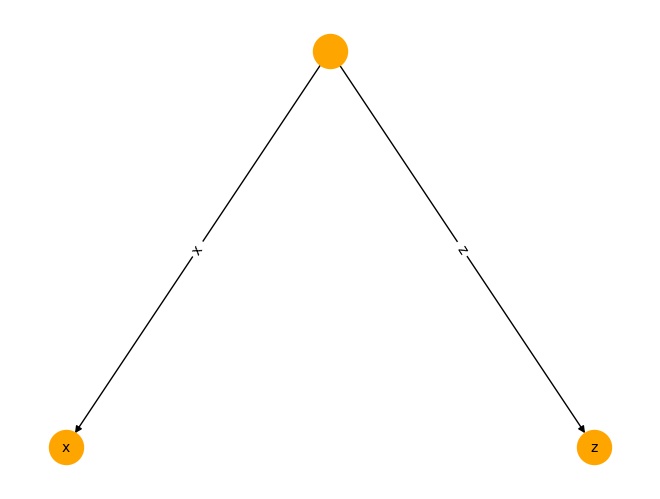

In [ ]:
from ferrmion.visualise import draw_tt
draw_tt(root)

# Algorithm 3

In [ ]:
from itertools import combinations
from typing import Iterable

def _qubit_term_weight(term: Iterable, comb: tuple[int, int, int]) -> int:
    """ Find the single-qubit Pauli-weight of majorana terms.

    If any pauli term is found an even number f times, we obtain I, weight = 0.
    If we find all three pauli terms, return I (with an imaginary ccoefficient), weight = 0
    If we find either one pauli or two then the weight 3 1.

    Args:
        term (Iterable): Indices of term in our majorana-hamiltonian.
        comb (tuple[int, int, int]): Combination of indices to weigh (x,y,z).

    Returns:
        int: Weight of the term.
    """
    term_array = np.array([t for t in term])
    odd_parity_paulis = np.array([np.count_nonzero(np.array(term_array-index))%2 for index in comb])
    non_commuting = np.sum(odd_parity_paulis) % 3
    return int(non_commuting!=0)

def _reduce_hamiltonian(majorana_ham: dict[tuple[int,...],float], parent_index:int, selection:tuple[int, int, int]) -> dict[tuple[int,...],float]:
    """Simplify the Hamiltonian.
    
    As we increase the qubit number, we iteratively remove majoranas
    which act trivially on the remaining qubits.
    We replace them with the index of their parent string
    as going forward they are identical to the parent string.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Current Hamiltonian.
        parent_index (int): Qubit index of the parent node.
        selection (tuple[int, int, int]): Indices of the majoranas to be replaced.
    
    Returns:
        dict[tuple[int,...],float]: Reduced Hamiltonian.
    """
    new_ham = {}
    for term, coeff in majorana_ham.items():
        new_term = (i if i not in selection else parent_index for i in term)
        if len(set(new_term)) != 1:
            new_ham[new_term] = coeff
    return new_ham

def hamiltonian_adaptive_ternary_tree(majorana_ham: dict[tuple[int,...],float], n_modes:int) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # We need 2*M +1 leaves and M nodes.
    nodes = {i:None for i in range(2*n_modes+1)}
    for i in range(n_modes):
        nodes[2*n_modes+1+i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = {*range(2*n_modes+1)}

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i:i for i in nodes}
    descendant_map = {i:i for i in nodes}

    total_weight = 0
    for i in range(n_modes):
        parent_index = 2*n_modes+1+i
        parent = nodes[parent_index]

        min = np.inf
        selection = None
        for comb in combinations(unassigned, 2):
            small_y = None
            small_x = None
            x_index, z_index = comb
            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2*n_modes:
                continue

            if small_x % 2 == 0:
                small_y = small_x+1
            else:
                small_y = small_x-1
            # We can't use this index for y a 
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                continue
            
            y_index = ancestor_map[small_y]

            if y_index in comb:
                continue

            if small_x %2 ==0:
                comb = np.array([x_index, y_index, z_index], dtype=np.uint)
            else:
                comb = np.array([y_index, x_index, z_index], dtype=np.uint)
            comb = [int(i) for i in comb]
            weight = np.sum([_qubit_term_weight(term, comb) for term in majorana_ham.keys()])
            if weight < min:
                min = weight
                selection = comb


        total_weight += min
        # Now find the Y pair of the x-node
        for (i,char) in zip(selection, ["x","y","z"]):
            if i in unassigned:
                unassigned.remove(i)

            if isinstance(nodes.get(i, None), TTNode):
                parent.add_child(which_child=char, child_node=nodes.get(i))
            else:
                parent.branch_majorana_indices[char] = i

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index
        
        unassigned.add(parent_index)

        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)

    if len(unassigned) != 1:
        raise ValueError("Not all nodes assigned by HATT.")

    root = nodes[unassigned.pop()]
    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    return tree



In [ ]:
majorana_ham = {(0,1):0.5j, (2,3):-0.5j, (4,5):-0.5j, (2,3,4,5):0.5}
n_modes = 3
hatt=hamiltonian_adaptive_ternary_tree(majorana_ham, n_modes)

In [ ]:
hatt.enumeration_scheme

{'': (2, 2), 'x': (1, 1), 'z': (0, 0)}

{'y': 5, 'xx': 2, 'xy': 3, 'xz': 4, 'zx': 0, 'zy': 1, 'zz': 6}

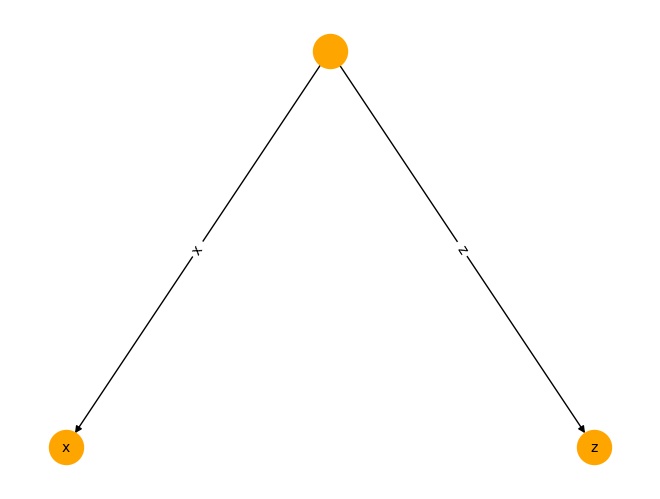

In [ ]:
draw_tt(hatt)
hatt.root_node.branch_majorana_indices